<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_09_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BLOG LINK:- https://colah.github.io/posts/2015-08-Understanding-LSTMs/

# Qus 01:

## Explain the purpose of the Forget Gate in LSTM. Explain the formula:
### ft = σ(Wf [ht−1, xt] + bf)


### ***Ans:***

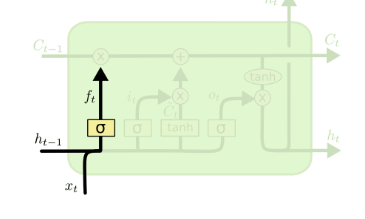

The forget gate in an LSTM decides how much of the previous cell state C(t−1) should be kept or discarded. For each element of the cell state, it outputs a value between 0 and 1, where 0 means forget completely and 1 means keep completely.

The equation is: ft = σ(Wf [h(t−1), xt] + bf)

- **σ (sigmoid):** squashes the result into the range 0 to 1.
- **Wf:** the weight matrix of the forget gate.
- **h(t−1):** the hidden state (short-term output) from the previous time step.
- **xt:** the input at the current time step.
- **[h(t−1), xt]:** the concatenation of h(t−1) and xt, which is multiplied by Wf as one vector.
- **bf:** the bias of the forget gate.

So the gate multiplies the weights with the concatenated vector, adds the bias, and passes the result through the sigmoid. The output ft is then multiplied element-wise with the previous cell state C(t−1), which removes the unimportant information from long-term memory and keeps the important part.

# Qus 02:

## Explain the role of the Input Gate in LSTM. Explain the formulas:
### it = σ(Wi [ht−1, xt] + bi)
###C̃t = tanh(Wc [ht−1, xt] + bc)

### ***Ans:***
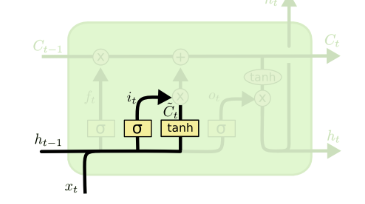


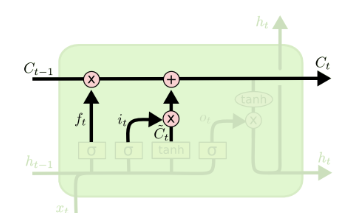


The input gate in an LSTM decides how much new information should be added to the cell state (long-term memory) at the current time step. It works together with a candidate cell state, which proposes the new information, while the gate controls how much of it is actually stored.

**Formula 1: it = σ(Wi [h(t−1), xt] + bi)**

- **σ (sigmoid):** squashes the result into the range 0 to 1.
- **Wi:** the weight matrix of the input gate.
- **[h(t−1), xt]:** the concatenation of the previous hidden state and the current input.
- **bi:** the bias of the input gate.
- **it:** the gate output. For each element, 0 means add nothing and 1 means add fully.

**Formula 2: C̃t = tanh(Wc [h(t−1), xt] + bc)**

- **tanh:** squashes the result into the range −1 to 1.
- **Wc:** the weight matrix for the candidate cell state.
- **bc:** the bias of the candidate cell state.
- **C̃t:** the candidate values, which is the new information that could be added to the cell state.

**How they work together:**

The candidate C̃t is multiplied element-wise with it, so only the selected part of the new information is kept. This is then added to the filtered old cell state:

Ct = ft ⊙ C(t−1) + it ⊙ C̃t

The forget gate removes the unwanted old information, and the input gate adds the important new information.

#Qus 03:

## Explain how the cell state is updated in LSTM using the formula:
### Ct = ft * Ct−1 + it * C̃t

### ***Ans:***

The cell state is the long-term memory of the LSTM. At each time step it is updated by combining the filtered old memory with the filtered new information.

**Formula: Ct = ft ⊙ C(t−1) + it ⊙ C̃t**

- **Ct:** the new cell state at the current time step.
- **C(t−1):** the previous cell state.
- **ft:** the forget gate output, with values between 0 and 1.
- **it:** the input gate output, with values between 0 and 1.
- **C̃t:** the candidate cell state, with values between −1 and 1.
- **⊙:** element-wise multiplication (the * in this formula).

**How the update works:**

1. **ft ⊙ C(t−1):** the forget gate scales each element of the old cell state. Values near 0 erase that information and values near 1 keep it.
2. **it ⊙ C̃t:** the input gate scales each element of the candidate. Values near 0 block the new information and values near 1 let it in.
3. **Addition:** the two parts are added to form the new cell state Ct.

So the cell state keeps what is still useful from the past and adds what is important from the present. Because the update uses addition rather than repeated multiplication through many layers, gradients flow more easily across time steps, which helps reduce the vanishing gradient problem. The new Ct is then passed to the next time step and also used to compute the hidden state ht through the output gate.


#Qus 04:

## Explain the purpose of the Output Gate in LSTM. Explain the formulas:
### ot = σ(Wo [ht−1, xt] + bo)
### ht = ot * tanh(Ct)


### ***Ans:***

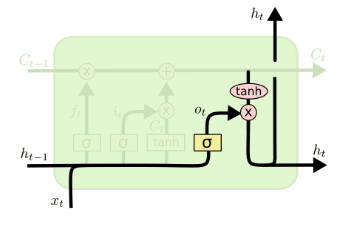

The output gate decides how much of the cell state (long-term memory) is exposed as the hidden state ht, which is the output of the current time step and is passed to the next time step.

**Formula 1: ot = σ(Wo [h(t−1), xt] + bo)**

- **σ (sigmoid):** squashes the result into the range 0 to 1.
- **Wo:** the weight matrix of the output gate.
- **[h(t−1), xt]:** the concatenation of the previous hidden state and the current input.
- **bo:** the bias of the output gate.
- **ot:** the gate output. For each element, 0 means output nothing and 1 means output fully.

**Formula 2: ht = ot ⊙ tanh(Ct)**

- **Ct:** the updated cell state from the current time step.
- **tanh(Ct):** squashes the cell state into the range −1 to 1.
- **⊙:** element-wise multiplication (the * in your formula).
- **ht:** the new hidden state (short-term memory and output).

**How it works:**

The cell state may hold a lot of information, but not all of it is needed at every step. The tanh scales Ct into a stable range, and ot then selects which parts of it are passed out as ht. The hidden state ht is used as the prediction at this step and is fed into the next time step as h(t−1). The cell state Ct itself is passed on unchanged to the next step.

# Qus 05:

## Why are three gates used in LSTM? Explain the responsibilities of Forget Gate, Input Gate, and Output Gate with formulas.

### ***Ans:***

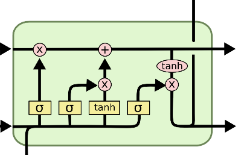

Three gates are used because LSTM memory needs three separate decisions at every time step: what old information to discard, what new information to store, and what part of the memory to expose as output. Splitting these jobs gives the network fine control over long-term memory, which a plain RNN lacks. This is what lets LSTM keep useful information over long sequences and reduces the vanishing gradient problem.

**1. Forget Gate: what to discard from old memory**

ft = σ(Wf [h(t−1), xt] + bf)

It outputs values between 0 and 1 for each element of the previous cell state C(t−1). Values near 0 erase that information and values near 1 keep it.


**2. Input Gate: what new information to store**

it = σ(Wi [h(t−1), xt] + bi)
C̃t = tanh(Wc [h(t−1), xt] + bc)

C̃t is the candidate new information (range −1 to 1), and it decides how much of it is allowed into the cell state.

**Cell state update (combines the forget and input gates):**

Ct = ft ⊙ C(t−1) + it ⊙ C̃t


**3. Output Gate: what to expose as output**

ot = σ(Wo [h(t−1), xt] + bo)
ht = ot ⊙ tanh(Ct)

It selects which parts of the cell state are passed out as the hidden state ht, which is used as the output at this step and as h(t−1) for the next step.


**Summary:**

| Gate | Responsibility | Acts on |
|---|---|---|
| Forget | Remove unneeded old information | C(t−1) |
| Input | Add important new information | C̃t |
| Output | Decide what is exposed as output | tanh(Ct) |


In all formulas, σ is the sigmoid function, W is a weight matrix, b is a bias, [h(t−1), xt] is the concatenation of the previous hidden state and current input, and ⊙ is element-wise multiplication.

# Qus 06:

## Differentiate between Forget Gate, Input Gate, and Output Gate in terms of functionality and formula.


### ***Ans:***

| Aspect | Forget Gate | Input Gate | Output Gate |
|---|---|---|---|
| Functionality | Decides how much of the old cell state to discard | Decides how much new information to add to the cell state | Decides how much of the cell state to expose as output |
| Acts on | Previous cell state C(t−1) | Candidate cell state C̃t | Current cell state Ct (through tanh) |
| Activation | Sigmoid (0 to 1) | Sigmoid (0 to 1) for the gate, tanh (−1 to 1) for the candidate | Sigmoid (0 to 1) |
| Gate formula | ft = σ(Wf [h(t−1), xt] + bf) | it = σ(Wi [h(t−1), xt] + bi) | ot = σ(Wo [h(t−1), xt] + bo) |
| Extra formula | None | C̃t = tanh(Wc [h(t−1), xt] + bc) | None |
| How the gate is applied | ft ⊙ C(t−1) | it ⊙ C̃t | ot ⊙ tanh(Ct) |
| Result | Filtered old memory | Filtered new memory | Hidden state ht |
| Effect of 0 | Old information is erased | New information is blocked | Nothing is output |
| Effect of 1 | Old information is fully kept | New information is fully added | Information is fully output |

**Combined updates:**

- Cell state: Ct = ft ⊙ C(t−1) + it ⊙ C̃t
- Hidden state: ht = ot ⊙ tanh(Ct)

The forget and input gates together update the cell state (long-term memory), while the output gate produces the hidden state (short-term memory and output) from it.

# Qus 07:
## Explain how Forget Gate controls old memory and Input Gate controls new memory in LSTM.

### ***Ans:***

**Cell state update formula:**

Ct = ft ⊙ C(t−1) + it ⊙ C̃t

**Forget Gate controls old memory**

ft = σ(Wf [h(t−1), xt] + bf)

- ft has values between 0 and 1 for each element of the previous cell state C(t−1).
- The term ft ⊙ C(t−1) scales the old memory element by element.
- If ft is near 0, that element of old memory is erased. If ft is near 1, it is kept.
- Example: if ft = 0.1 for an element holding 0.8, the result is 0.08, so most of it is forgotten.

**Input Gate controls new memory**

it = σ(Wi [h(t−1), xt] + bi)
C̃t = tanh(Wc [h(t−1), xt] + bc)

- C̃t is the candidate new information, with values between −1 and 1.
- it has values between 0 and 1 and decides how much of the candidate is allowed in.
- The term it ⊙ C̃t scales the new memory element by element.
- If it is near 0, the new information is blocked. If it is near 1, it is added fully.
- Example: if it = 0.9 for a candidate value 0.5, the result is 0.45, so most of it is stored.

**Combined effect**

The two filtered parts are added to form the new cell state Ct. The forget gate decides what remains of the old memory, the input gate decides what is added from the new input, and together they update the long-term memory at each time step.


# Qus 08:

## Explain how the Output Gate determines the hidden state in LSTM.

### ***Ans:***

The output gate decides which parts of the updated cell state Ct are exposed as the hidden state ht, which is the output of the current time step.

**Formulas**

ot = σ(Wo [h(t−1), xt] + bo)

ht = ot ⊙ tanh(Ct)

**How it determines ht**

1. **Gate computation:** ot is computed from the previous hidden state and the current input. Each element is between 0 and 1.
2. **Cell state scaling:** tanh(Ct) squashes the updated cell state into the range −1 to 1.
3. **Filtering:** ot is multiplied element-wise with tanh(Ct). Elements where ot is near 0 are hidden, and elements where ot is near 1 are passed out.
4. **Result:** the filtered values form ht.

Example: if tanh(Ct) = 0.6 for an element and ot = 0.9, then ht = 0.54 for that element. If ot = 0.1, then ht = 0.06, so that part of the memory is mostly hidden.

**Role of ht**

ht is used as the output (prediction) at the current step and is passed to the next step as h(t−1). The cell state Ct is not changed by the output gate. It keeps the full memory, and the output gate only controls how much of it is visible in ht.

# Qus 09:

# “Forget Gate removes unnecessary information, Input Gate adds important information, and Output Gate controls the final output.” Explain this statement with formulas.


### ***Ans:***

**1. Forget Gate removes unnecessary information**

ft = σ(Wf [h(t−1), xt] + bf)

The term ft ⊙ C(t−1) scales each element of the old cell state by a value between 0 and 1. Values near 0 erase that information, so unnecessary old memory is removed.

**2. Input Gate adds important information**

it = σ(Wi [h(t−1), xt] + bi)
C̃t = tanh(Wc [h(t−1), xt] + bc)

The term it ⊙ C̃t scales the candidate new information. Values near 1 let important new information into the cell state.

**Cell state update (forget and input gates combined)**

Ct = ft ⊙ C(t−1) + it ⊙ C̃t

**3. Output Gate controls the final output**

ot = σ(Wo [h(t−1), xt] + bo)
ht = ot ⊙ tanh(Ct)

ot selects which parts of the cell state are exposed. ht is the final output of the current step and is passed to the next step as h(t−1).

**Summary**

| Statement | Gate | Key formula |
|---|---|---|
| Removes unnecessary information | Forget | ft ⊙ C(t−1) |
| Adds important information | Input | it ⊙ C̃t |
| Controls the final output | Output | ot ⊙ tanh(Ct) |

In all formulas, σ is the sigmoid function, W is a weight matrix, b is a bias, [h(t−1), xt] is the concatenation of the previous hidden state and current input, and ⊙ is element-wise multiplication.

# Qus 10:

## Explain the complete workflow of an LSTM cell using the formulas of Forget Gate, Input Gate, cell state update, and Output Gate.


### ***Ans:***

# Complete Workflow of an LSTM Cell

At time step t, the LSTM cell receives the previous hidden state $h_{t-1}$, the previous cell state $C_{t-1}$, and the current input $x_t$. It processes them in four stages.

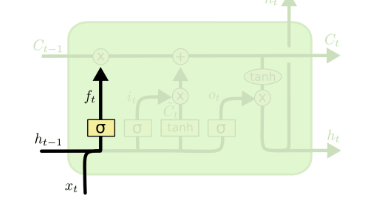

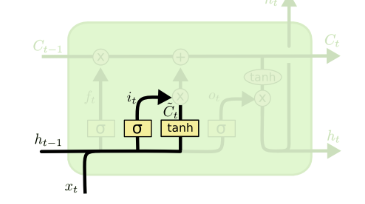


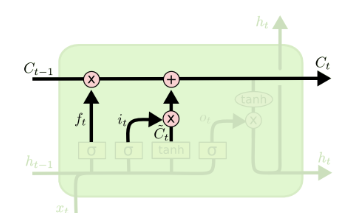


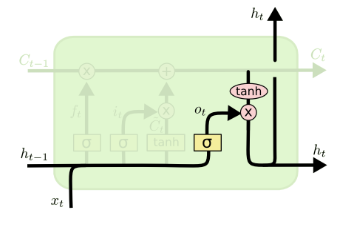


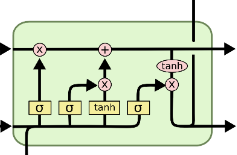

## Step 1: Forget Gate (what to discard from old memory)

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

$f_t$ has values between 0 and 1 for each element of $C_{t-1}$. A value near 0 erases that information and a value near 1 keeps it.

## Step 2: Input Gate (what new information to store)

$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$

$$\tilde{C}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$

$\tilde{C}_t$ is the candidate new information (range -1 to 1), and $i_t$ controls how much of it is allowed into the cell state.

## Step 3: Cell State Update (combine old and new memory)

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

The forget gate filters the old memory, the input gate filters the new memory, and the two are added to form the new long-term memory $C_t$.

## Step 4: Output Gate (what to expose as output)

$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$

$$h_t = o_t \odot \tanh(C_t)$$

$o_t$ selects which parts of the cell state are passed out as the hidden state $h_t$.

## Outputs of the Cell

- $C_t$: the new cell state (long-term memory), passed to the next time step.
- $h_t$: the new hidden state (short-term memory and output), used as the prediction at this step and passed to the next step as $h_{t-1}$.

## Flow Summary

1. Forget gate takes $h_{t-1}$ and $x_t$ and gives $f_t$.
2. Input gate takes $h_{t-1}$ and $x_t$ and gives $i_t$ and $\tilde{C}_t$.
3. Cell state update takes $f_t$, $C_{t-1}$, $i_t$, $\tilde{C}_t$ and gives $C_t$.
4. Output gate takes $h_{t-1}$, $x_t$, $C_t$ and gives $o_t$ and $h_t$.

## Notation

- $\sigma$ is the sigmoid function (output 0 to 1).
- $\tanh$ is the hyperbolic tangent (output -1 to 1).
- $W$ is a weight matrix and $b$ is a bias.
- $[h_{t-1}, x_t]$ is the concatenation of the previous hidden state and the current input.
- $\odot$ is element-wise multiplication.